In [2]:
# ! pip install -U "jax[cuda12]"
! pip install -U equinox diffrax distrax optax

In [3]:
import functools

import distrax
import jax
import jax.numpy as jnp
import jax.random as jrnd
import optax
import equinox as eqx

import diffrax
from diffrax import ODETerm, diffeqsolve

import matplotlib
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

This tutorial aims to code Continuous Normalizing Flows (NFlows) in jax, using equinox and diffrax.

We recomend the reader the following papers.
* [Neural ODEs](https://arxiv.org/abs/1806.07366)
* [NFlows review](https://arxiv.org/abs/1912.02762)

We will focuse on the optimization of the forward and reverse KL divergence, as these are both, well use examples in ML.





The change of variable formula allows us to link two different probabilistic distributions,

$$
p_x(x) = p_z(z) |\text{det}\; J_{T}(z)|^{-1},
$$
where, $\text{det}\; J_{T}(z)$ is the determinant of Jacobian of the function $T(z) = x$ and $T^{-1}(x) = z$.
This volumen term can be computed through a set or joint ODEs,
$$
\partial_t \begin{bmatrix}
\mathbf{z}(t) \\
\log \rho_\phi(\mathbf{z}(t))
\end{bmatrix} =\begin{bmatrix}
g_\phi(\mathbf{z}(t),t) \\
-\nabla_{\mathbf{x}} \cdot g_\phi(\mathbf{z}(t),t)
\end{bmatrix},
$$
where the first term when integrated mimics the change from $x$ to $z$ or viserversa, and the second term indicates the change of the volumne part.
This set of ODEs are reversible, meaning the same of equations can be run in "reverse time".

In [4]:
# NN to parameterize the set of ODE equations

# g_\phi(z(t),t)
class Flow(eqx.Module):
  linear_in: eqx.nn.Linear
  blocks: list
  linear_out: eqx.nn.Linear
  din: int = eqx.field(static=True)
  dim: int = eqx.field(static=True)

  def __init__(self, din: int, dim: int, key):
    self.din, self.dim = din, dim
    k_in, k_out, *k_blocks = jrnd.split(key, 5)
    self.linear_in = eqx.nn.Linear(din + 1, dim, key=k_in)
    self.blocks = [eqx.nn.Linear(dim, dim, key=k) for k in k_blocks]
    self.linear_out = eqx.nn.Linear(dim, din, key=k_out)

  def __call__(self, x, t):
    x = jnp.concatenate([x, t], axis=-1)
    x = self.linear_in(x)
    x = jnp.tanh(x)
    for block in self.blocks:
      x = block(x)
      x = jnp.tanh(x)
    x = self.linear_out(x)

    return x

# [g_\phi(\mathbf{z}(t),t) , -\nabla_{\mathbf{x}} \cdot g_\phi(\mathbf{z}(t),t)]
class CNF(eqx.Module):
  flow: Flow
  din: int = eqx.field(static=True)
  dim: int = eqx.field(static=True)

  def __init__(self, din: int, dim: int, key):
    self.din, self.dim = din, dim
    self.flow = Flow(din, dim, key)

  def __call__(self, states, t):

    x, log_px = states[:-1], states[-1:]
    dz, f_vjp = jax.vjp(self.flow, x, t)
    x_ones = jnp.ones((self.din))
    (dtrJ, _) = f_vjp(x_ones)
    dtrJ = jnp.sum(dtrJ)

    return jnp.concatenate([dz, -dtrJ[None]], axis=-1)

In [5]:
data_dim: int = 1 # number of dimensions
model_dim: int = 264 # number of hidden neurons / layer
key = jrnd.PRNGKey(0)

flow_model = CNF(data_dim, model_dim, key)
pred_flow = flow_model(jnp.ones((2)), jnp.array([0.]))
print(pred_flow)

# vmap to account for the batchsize dimension
@functools.partial(jax.vmap, in_axes=(None, 0, 0), out_axes=0)
def forward(model, x, t):
  return model(x, t)

pred_flow_bs = forward(flow_model, jnp.ones((2,2)), jnp.array([[0.],[1.]]))
print(pred_flow_bs)

[0.02815067 0.01171981]
[[0.02815067 0.01171981]
 [0.03231528 0.00905893]]


# Forward KL divergence.
The forward KL divergence between the target distribution $p^∗_x(x)$ and the flow-based model
$p_x(x; \theta)$ can be written as follows,
$$
{\cal L}(\theta) = D_{KL}[p^∗_x(x) ||p_x(x; \theta) ] = - \mathbb{E}_{p^∗_x(x)}[\log p_x(x; \theta)] + const, \\
{\cal L}(\theta) = - \mathbb{E}_{p^∗_x(x)}[\log p_z(T^{-1}(x,\theta))+ \log |\text{det}\; J_{T^{-1}}(x, \theta)|] + const,
$$
the expecation value is constructed using only samples from the target distribution, $p^∗_x(x)$.
This allows us to compute the forward KL divergence using Monte Carlo,
$$
{\cal L}(\theta) \approx \frac{1}{N} \sum_i^N \log p_z(T^{-1}(x,\theta))+ \log |\text{det}\; J_{T^{-1}}(x, \theta)| + const
$$

Let's code this using the CNFlows.


In [6]:
# define the base distribution p_z(z) using a single Gaussian distribution

base_dist = distrax.MultivariateNormalDiag(jnp.array([0.]), jnp.array([1.]))
def sample_pz(key, bs):
  z = base_dist.sample(seed=key, sample_shape=(bs,))
  log_pz = base_dist.log_prob(z)
  return jnp.concatenate([z,log_pz[:,None]], axis=-1)

key = jrnd.PRNGKey(0)
z_and_logpz = sample_pz(key, 100)

In [7]:
# let's define the p^∗_x(x) (data distribution) using a mixture of gaussians.

base_dist0 = distrax.MultivariateNormalDiag(jnp.array([-2.]), jnp.array([0.5]))
base_dist1 = distrax.MultivariateNormalDiag(jnp.array([2.]), jnp.array([0.3]))
bimod_dist = distrax.MixtureOfTwo(0.5,base_dist0,base_dist1)

key = jrnd.PRNGKey(0)
_,key = jrnd.split(key)
x = bimod_dist.sample(seed=key, sample_shape=(100,1))
x = jnp.linspace(-10,10,100)
x = x[:,None]
p0 = bimod_dist.prob(x)

def sample_data_dist(key, bs): #bs is number of samples
  x = bimod_dist.sample(seed=key, sample_shape=(bs,))
  p0 = bimod_dist.prob(x)
  return jnp.concatenate([x,jnp.log(p0)[:,None]], axis=-1)

x_and_logpx = sample_data_dist(key, 2)

In [8]:
# Forward KL divergence
def fwd_kl_div(flow_model, x_and_logpx):
  t0 = 0.
  t1 = 1.
  dt0 = t1 - t0
  vector_field = lambda t, x, args: forward(flow_model, x, t*jnp.ones((x.shape[0],1)))
  term = ODETerm(vector_field)
  sol = diffeqsolve(term, diffrax.Tsit5(), t0, t1, dt0, x_and_logpx,
                    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-6),
                    saveat=diffrax.SaveAt(ts=jnp.array([0., 1.])))
  z_and_logjac = sol.ys[-1,:,:]
  z = z_and_logjac[:,:-1]
  log_jac = z_and_logjac[:,-1]
  return -jnp.mean(base_dist.log_prob(z) - log_jac)

In [9]:
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adamw(optax.schedules.exponential_decay(2e-3, transition_steps=1, decay_rate=0.95),
                weight_decay=1E-5),
)
opt_state = optimizer.init(eqx.filter(flow_model, eqx.is_inexact_array))

@eqx.filter_jit
def train_step(flow_model, opt_state, x_and_logpx):
  loss, grads = eqx.filter_value_and_grad(fwd_kl_div)(flow_model, x_and_logpx)
  updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(flow_model, eqx.is_inexact_array))
  flow_model = eqx.apply_updates(flow_model, updates)
  return loss, flow_model, opt_state

for itr in range(50):
    _,key = jrnd.split(key)
    x_and_logpx = sample_data_dist(key, 32) #sample 32 points form p^*_x(x)
    x_and_logpx = x_and_logpx.at[:,-1].set(0.)
    loss, flow_model, opt_state = train_step(flow_model, opt_state, x_and_logpx)
    print(itr, loss)

0 2.8690689059127674
1 1.9184231087785615
2 2.5790986028645357
3 2.2344531393447764
4 1.812267253287817
5 1.6822177910580987
6 1.7523893104855974
7 2.0969068099637886
8 2.2716312255480555
9 2.4155464919988643
10 1.8157331010533726
11 1.4398434821267445
12 1.3905951153493208
13 1.5872672515206723
14 1.8439416539421754
15 1.6797369247555851
16 1.4126950633555637
17 1.3693222606268403
18 1.4152377689401914
19 1.462256048612491
20 1.4130645441859158
21 1.3326076474815323
22 1.3253881603439437
23 1.296609824104243
24 1.4815494117900476
25 1.377708788629632
26 1.5000034804234934
27 1.294672927900182
28 1.341049665398313
29 1.1246737892207341
30 1.369140214486766
31 1.2815663295432485
32 1.184571411257672
33 1.1668200850102273
34 1.3848891033491466
35 1.2818238186478157
36 1.183672427368091
37 1.2516329576827223
38 1.2627366134616003
39 1.052154789070946
40 1.2345134433591471
41 1.234547813862843
42 1.708138011150574
43 1.2330175858924783
44 1.271248770726414
45 1.1390585902249681
46 1.266393

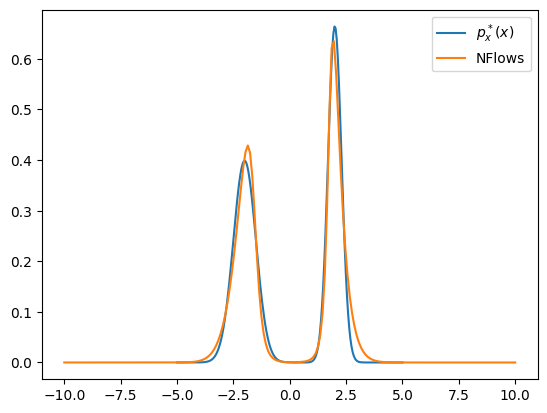

In [10]:
# plot the distribution
x = jnp.linspace(-5,5,200)
x = x[:,None]
p0 = bimod_dist.prob(x)

plt.plot(x,p0,label=r'$p^*_x(x)$')

x = jnp.linspace(-10,10,200)
x = x[:,None]
x_and_logpx = jnp.concatenate([x,jnp.zeros((x.shape[0],1))], axis=-1)
t0 = 0.
t1 = 1.
dt0 = t1 - t0
vector_field = lambda t, x, args: forward(flow_model, x, t*jnp.ones((x.shape[0],1)))

term = ODETerm(vector_field)
sol = diffeqsolve(term, diffrax.Tsit5(), t0, t1, dt0, x_and_logpx, stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-6), saveat=diffrax.SaveAt(ts=jnp.array([0., 1.])))
z_and_logpz = sol.ys[-1,:,:]
z = z_and_logpz[:,:-1]
log_jac = z_and_logpz[:,-1:]
log_px_pred = base_dist.log_prob(z)[:,None] - log_jac

plt.plot(x,jnp.exp(log_px_pred).flatten(),label='NFlows')
plt.legend()

# Reverse KL Divergence.
Minimizing the reverse KL divergence,
$$
{\cal L}(\theta) = D_{KL}[p_x(x; \theta) || p^∗_x(x) ] = \mathbb{E}_{p_x(x,\theta)}[\log p_x(x; \theta)- \log p^∗_x(x)] , \\
{\cal L}(\theta) = \mathbb{E}_{p_z(z)}[\log p_z(z)- \log |\text{det}\; J_{T}(z, \theta)| - \log p^∗_x(x)]
$$
The last term in reverse KL is tricky as it means we should be able to compute the density of the data distribution.
Similarly to forward KL, we can compute it using MC,
$$
{\cal L}(\theta) \approx \frac{1}{N} \sum_i^N \log p_z(z_i)- \log |\text{det}\; J_{T}(z_i, \theta)| - \log p^∗_x(T(z_i))
$$

Let's code this using the CNFlows.

In [11]:
def rev_kl_div(flow_model, z_and_logpz):
  t0 = 0.
  t1 = 1.
  dt0 = t1 - t0
  vector_field = lambda t, x, args: forward(flow_model, x, t*jnp.ones((x.shape[0],1)))
  term = ODETerm(vector_field)
  sol = diffeqsolve(term, diffrax.Tsit5(), t1, t0, -dt0, z_and_logpz, stepsize_controller=diffrax.PIDController(rtol=1e-4, atol=1e-4), saveat=diffrax.SaveAt(ts=jnp.array([1., 0.])))
  x_and_logpx = sol.ys[-1,:,:]
  x = x_and_logpx[:,:-1]
  log_px = x_and_logpx[:,-1:]
  log_px_true = jnp.log(bimod_dist.prob(x))[:,None]
  return jnp.mean(log_px - log_px_true)

In [12]:
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adamw(optax.schedules.exponential_decay(1e-5, transition_steps=1, decay_rate=0.95),
                weight_decay=1E-5),
)
opt_state = optimizer.init(eqx.filter(flow_model, eqx.is_inexact_array))

@eqx.filter_jit
def train_step(flow_model, opt_state, z_and_logpz):
  loss, grads = eqx.filter_value_and_grad(rev_kl_div)(flow_model, z_and_logpz)
  updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(flow_model, eqx.is_inexact_array))
  flow_model = eqx.apply_updates(flow_model, updates)
  return loss, flow_model, opt_state

for itr in range(20):
    _,key = jrnd.split(key)
    z_and_logpz = sample_pz(key, 64)
    loss, flow_model, opt_state = train_step(flow_model, opt_state, z_and_logpz)
    if itr % 1 == 0:
      _,key = jrnd.split(key)
      z_and_logpz = sample_pz(key, 128)
      loss_val = rev_kl_div(flow_model, z_and_logpz)
      print(itr, loss, loss_val)

0 0.14611341281813373 0.37085298749283513
1 0.016285150842480896 0.13664246406123398
2 0.14433929264777218 0.013023152206854774
3 0.12043418408184678 0.09380345197357491
4 0.006108539229127499 0.09385165021529922
5 0.0649614569217696 0.008471242566792294
6 0.2138721752850139 0.2810771305942826
7 0.2527159432202958 0.10332939136497948
8 0.0816255194058749 0.08536513461243037
9 0.19176937932300772 0.11822017771899129
10 -0.007260077082772269 0.11458165058782405
11 0.12311161073350121 0.140853197276253
12 -0.010062936980511687 0.06554942234996762
13 0.018950766274080398 0.11178187226155134
14 0.1679149157238481 0.14408803365538647
15 0.029948095662472474 0.1472656880411713
16 0.014140345353772725 0.04709871767855479
17 0.19646505094668013 0.11611679895849464
18 0.34369285268549804 0.1533749813259296
19 0.18635940744491292 0.12391595569538208


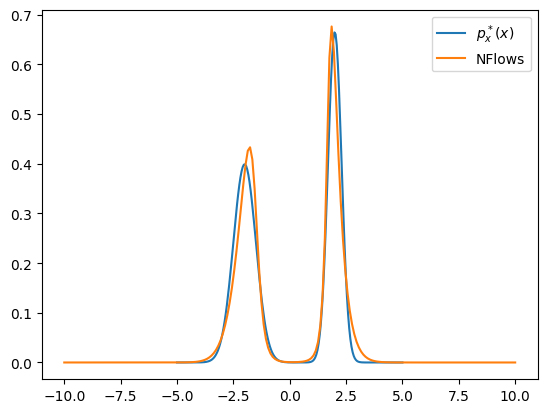

In [13]:
# plot the distribution
x = jnp.linspace(-5,5,200)
x = x[:,None]
p0 = bimod_dist.prob(x)

plt.plot(x,p0,label=r'$p^*_x(x)$')

x = jnp.linspace(-10,10,200)
x = x[:,None]
x_and_logpx = jnp.concatenate([x,jnp.zeros((x.shape[0],1))], axis=-1)
t0 = 0.
t1 = 1.
dt0 = t1 - t0
vector_field = lambda t, x, args: forward(flow_model, x, t*jnp.ones((x.shape[0],1)))

term = ODETerm(vector_field)
sol = diffeqsolve(term, diffrax.Tsit5(), t0, t1, dt0, x_and_logpx, stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-6), saveat=diffrax.SaveAt(ts=jnp.array([0., 1.])))
z_and_logpz = sol.ys[-1,:,:]
z = z_and_logpz[:,:-1]
log_jac = z_and_logpz[:,-1:]
log_px_pred = base_dist.log_prob(z)[:,None] - log_jac

plt.plot(x,jnp.exp(log_px_pred).flatten(),label='NFlows')
plt.legend()

In [14]:
# compute the density using numerical integration.
def rho_rev(model, x):
  x_and_logpx = jnp.concatenate([x,jnp.zeros((x.shape[0],1))], axis=-1)

  t0 = 0.
  t1 = 1.
  dt0 = t1 - t0
  vector_field = lambda t, x, args: forward(model, x, t*jnp.ones((x.shape[0],1)))

  term = ODETerm(vector_field)
  sol = diffeqsolve(term, diffrax.Tsit5(), t0, t1, dt0, x_and_logpx, stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-6), saveat=diffrax.SaveAt(ts=jnp.array([0., 1.])))
  z_and_logpz = sol.ys[-1,:,:]
  z = z_and_logpz[:,:-1]
  log_jac = z_and_logpz[:,-1:]
  log_px = base_dist.log_prob(z)[:,None] - log_jac
  return jnp.exp(log_px)

def integral(model, x_grid):
  p_x = rho_rev(model, x_grid)
  return jnp.trapezoid(p_x.flatten(), dx=float(x_grid[1,0]-x_grid[0,0])), p_x

In [15]:
x_grid = jnp.linspace(-12,12,1000)[:,None]
norm_val, rho_pred = integral(flow_model,x_grid)
print('Integral value', norm_val)

Integral value 0.9999991590580588
